In [1]:
import scipy.optimize as sci_opt
import requests
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate

In [4]:
API_KEY     = "38b180a56f95c90b99575163d54d922a8e670f46"
BASE_FOLDER = Path(r"C:\Users\carle\Documents\Portafolio Optimization\Tiingo-data\data-sets")

def get_or_create_dataset(assets, start_date="2000-01-01", end_date="2026-01-01", api_key=API_KEY):
    # Normalize assets
    assets = [asset.upper().strip() for asset in assets]

    # Create a consistent file name
    # sorted() ensures ['KO','WMT','VOO'] and ['VOO','KO','WMT'] generate the same name
    file_name = "_".join(sorted(assets)) + ".csv"
    file_path = BASE_FOLDER / file_name

    # Create folder if it doesn't exist
    BASE_FOLDER.mkdir(parents=True, exist_ok=True)

    # If it already exists, load it
    if file_path.exists():
        print(f"File found: {file_path}")
        return pd.read_csv(file_path, index_col=0, parse_dates=True)

    # If it doesn't exist, download it
    print(f"File not found. Downloading data for: {assets}")
    headers  = {"Content-Type": "application/json", "Authorization": f"Token {api_key}"}
    all_data = {}

    for asset in assets:
        url      = f"https://api.tiingo.com/tiingo/daily/{asset}/prices?startDate={start_date}&endDate={end_date}"
        response = requests.get(url, headers=headers)
        response.raise_for_status()
        data = response.json()

        if not data:
            raise ValueError(f"No data found for {asset}")

        df         = pd.DataFrame(data)
        df["date"] = pd.to_datetime(df["date"]).dt.tz_localize(None)
        df.set_index("date", inplace=True)
        all_data[asset] = df["adjClose"]

    # Join all closing prices into a single DataFrame
    price_data_frame_full = pd.DataFrame(all_data)

    # Save CSV
    price_data_frame_full.to_csv(file_path)
    print(f"File saved at: {file_path}")
    return price_data_frame_full

In [5]:
def get_metrics(weights, log_return, risk_free=0):
    # Convert to a numpy array
    weights = np.array(weights)

    # Calculate annualized return
    ret = np.sum(log_return.mean() * weights) * 252

    # Calculate the volatility
    vol = np.sqrt(
        np.dot(weights.T, np.dot(log_return.cov() * 252, weights))  # [ weights.T * Cov(Matrix) * weights ] = (1,1)
    )

    # Calculate the Sharpe ratio
    sr = (ret - risk_free) / vol

    return np.array([ret, vol, sr])


def optimize(log_return, num_of_assets, risk_free=0):
    # We have to negativize the Sharpe ratio, in order to minimize
    def grab_negative_sharpe(weights): return get_metrics(weights, log_return, risk_free)[2] * -1
    def grab_volatility(weights):      return get_metrics(weights, log_return, risk_free)[1]

    # Scipy requires equality constraints (type='eq') to return 0
    # We need the weights to sum to 1, so we return sum - 1
    def check_sum(weights): return np.sum(weights) - 1

    # Sequence of (min, max) pairs for each element in x
    bounds = tuple((0, 1) for _ in range(num_of_assets))

    # Constraint weights = 100%
    constraints = {'type': 'eq', 'fun': check_sum}

    # Initial guess: equal distribution
    init_guess = [1 / num_of_assets] * num_of_assets

    # Perform the operation to maximize Sharpe ratio
    opt_sharpe = sci_opt.minimize(grab_negative_sharpe, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)

    # Perform the operation to minimize volatility
    opt_vol = sci_opt.minimize(grab_volatility, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)

    return opt_sharpe.x, opt_vol.x


def print_results(assets, log_return, opt_sharpe_weights, opt_vol_weights, risk_free=0):
    width = 74

    for title, weights in [("MAX SHARPE RATIO", opt_sharpe_weights), ("MIN VOLATILITY", opt_vol_weights)]:
        metrics = get_metrics(weights, log_return, risk_free)
        print()
        print('╔' + '═' * width + '╗')
        print('║' + title.center(width) + '║')
        print('╠' + '═' * width + '╣')

        metrics_data = [
            ['Returns',      f"{metrics[0]:.6f}"],
            ['Volatility',   f"{metrics[1]:.6f}"],
            ['Sharpe Ratio', f"{metrics[2]:.6f}"],
        ]
        table = tabulate(metrics_data, headers=['Metric', 'Value'], tablefmt='simple', colalign=('left', 'right'))
        for line in table.splitlines():
            print('║  ' + line.ljust(width - 2) + '║')

        print('╠' + '═' * width + '╣')
        print('║' + ' WEIGHTS'.ljust(width) + '║')
        print('╠' + '═' * width + '╣')

        weights_data = [[sym, f"{w:.6f}"] for sym, w in zip(assets, weights)]
        w_table = tabulate(weights_data, headers=['Symbol', 'Weight'], tablefmt='simple', colalign=('left', 'right'))
        for line in w_table.splitlines():
            print('║  ' + line.ljust(width - 2) + '║')

        print('╚' + '═' * width + '╝')


def run_backtest(price_test, weights, label, assets, initial_capital=10000):
    # Check daily return, % of change each day
    daily_return = price_test.pct_change()
    # Clean NaN of the first line
    daily_return = daily_return.dropna()

    # We can see this as a matrix multiplication (nx15)x(15x1), so we have (nx1) for each asset
    portfolio_daily_return = (daily_return * weights).sum(axis=1)
    portfolio_value        = initial_capital * (1 + portfolio_daily_return).cumprod()

    # Real metrics
    total_return  = (portfolio_value.iloc[-1] / initial_capital) - 1
    annual_return = (1 + total_return) ** (252 / len(portfolio_value)) - 1
    annual_vol    = portfolio_daily_return.std() * np.sqrt(252)
    sharpe        = annual_return / annual_vol

    # Max Drawdown
    rolling_max  = portfolio_value.cummax()
    drawdown     = (portfolio_value - rolling_max) / rolling_max
    max_drawdown = drawdown.min()

    # Result
    result_df = pd.DataFrame({'Portfolio Value': portfolio_value})

    width = 74
    print()
    print('╔' + '═' * width + '╗')
    print('║' + f'BACKTEST — {label}'.center(width) + '║')
    print('╠' + '═' * width + '╣')

    metrics_data = [
        ['Total Return',      f"{total_return*100:.2f}%"],
        ['Annual Return',     f"{annual_return*100:.2f}%"],
        ['Annual Volatility', f"{annual_vol*100:.2f}%"],
        ['Sharpe Ratio',      f"{sharpe:.4f}"],
        ['Max Drawdown',      f"{max_drawdown*100:.2f}%"],
        ['Final Capital',     f"${portfolio_value.iloc[-1]:,.2f}"],
    ]
    table = tabulate(metrics_data, headers=['Metric', 'Value'], tablefmt='simple', colalign=('left', 'right'))
    for line in table.splitlines():
        print('║  ' + line.ljust(width - 2) + '║')

    print('╠' + '═' * width + '╣')

    weights_data = [[sym, f"{w*100:.2f}%"] for sym, w in zip(assets, weights)]
    w_table = tabulate(weights_data, headers=['Symbol', 'Weight'], tablefmt='simple', colalign=('left', 'right'))
    for line in w_table.splitlines():
        print('║  ' + line.ljust(width - 2) + '║')

    print('╚' + '═' * width + '╝')

    return result_df


def run_all(price_data_frame_full, assets, train_start, train_end, test_start, test_end, risk_free=0, initial_capital=10000):
    # Split data
    price_data_frame = price_data_frame_full.loc[train_start:train_end].dropna().copy()  # ← Train
    price_test       = price_data_frame_full.loc[test_start:test_end].dropna().copy()    # ← Test

    print(price_data_frame.head())
    print(price_data_frame.tail())

    # Calculate the log return + 1      Ex. 1.054
    log_return    = np.log(1 + price_data_frame.pct_change()).dropna()
    num_of_assets = len(assets)

    # Optimize
    opt_sharpe_weights, opt_vol_weights = optimize(log_return, num_of_assets, risk_free)

    # Print optimization results
    print_results(assets, log_return, opt_sharpe_weights, opt_vol_weights, risk_free)

    # Run backtests
    bt_max_sharpe = run_backtest(price_test, opt_sharpe_weights, "MAX SHARPE RATIO", assets, initial_capital)
    bt_min_vol    = run_backtest(price_test, opt_vol_weights,    "MIN VOLATILITY",   assets, initial_capital)

    # Visual comparison
    fig, ax = plt.subplots(figsize=(12, 5))
    bt_max_sharpe['Portfolio Value'].plot(ax=ax, label='Max Sharpe',    color='steelblue',  linewidth=2)
    bt_min_vol['Portfolio Value'].plot(ax=ax,    label='Min Volatility', color='darkorange', linewidth=2)
    ax.axhline(initial_capital, color='gray', linestyle='--', linewidth=1, label='Initial Capital')
    ax.set_title(f'Backtest — Portfolio Performance ({test_start} → {test_end})')
    ax.set_ylabel('Value ($)')
    ax.set_xlabel('Date')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# Rate Hike Shock 2022

> *A classical mean-variance optimizer trained only on historical data  
> cannot anticipate a regime change like the one seen in 2022.*

---

## Background

During 2020 and 2021, the Federal Reserve kept interest rates near zero to stimulate
the post-COVID economy. Low rates generally cause a massive wave of liquidity in the
market — nobody wants to save, so spending and investing become more attractive,
pushing the prices of almost every asset class higher: tech stocks, bonds, real estate,
and more. This generated inflation by late 2021.

By March 2022, rates were hiked to 4.5% in less than a year — a very fast hike.
Moreover, the conflict between Russia and Ukraine sent energy prices surging, adding
more pressure to an already inflationary environment. In 2022 the historical correlation
between stocks and bonds was not enough to serve as an escape for investors when
equities dropped.

---

## Assets

| Ticker | Description |
|--------|-------------|
| `AAPL` `MSFT` `GOOGL` `AMZN` | Major tech companies, highly sensitive to interest rates |
| `JPM` | The largest bank in the U.S. — banks have a complex relationship with rates |
| `JNJ` `PG` `KO` `WMT` | Classic defensive stocks, consumer staples companies |
| `XOM` | ExxonMobil, the major oil company |
| `BRK-B` | Berkshire Hathaway, Warren Buffett's conglomerate |
| `VOO` | The S&P 500 ETF, included as a general market benchmark |
| `GLD` | The gold ETF, historically the ultimate hedge against inflation |
| `TLT` | Long-term treasury bond ETF — the **trap asset** of the experiment, included precisely because we knew the optimizer would overweight it, having learned over 11 years that TLT is the best diversifier |
| `VNQ` | The REITs ETF — real estate is highly sensitive to rates because it is debt-financed |

---

## Model Limitation

This model learned from years of historical correlation between equities and low-risk
assets like treasury bonds. A classical mean-variance optimizer trained only on
historical data cannot anticipate a regime change like the one seen in 2022.

File not found. Downloading data for: ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'JPM', 'JNJ', 'PG', 'KO', 'WMT', 'XOM', 'BRK-B', 'VOO', 'GLD', 'TLT', 'VNQ']
File saved at: C:\Users\carle\Documents\Portafolio Optimization\Tiingo-data\data-sets\AAPL_AMZN_BRK-B_GLD_GOOGL_JNJ_JPM_KO_MSFT_PG_TLT_VNQ_VOO_WMT_XOM.csv
                AAPL       MSFT      GOOGL    AMZN        JPM        JNJ  \
date                                                                       
2010-09-09  7.882131  18.161528  11.842965  7.0190  26.679190  38.183230   
2010-09-10  7.892319  18.040502  11.841971  7.1220  26.452982  38.285358   
2010-09-13  8.001081  18.993585  11.994428  7.2535  27.357812  38.502381   
2010-09-14  8.031642  18.933072  11.948666  7.2875  27.091686  38.668339   
2010-09-15  8.096361  18.997367  11.953889  7.2725  27.264668  38.968341   

                   PG         KO        WMT        XOM  BRK-B        VOO  \
date                                                                       
2010-09-09 

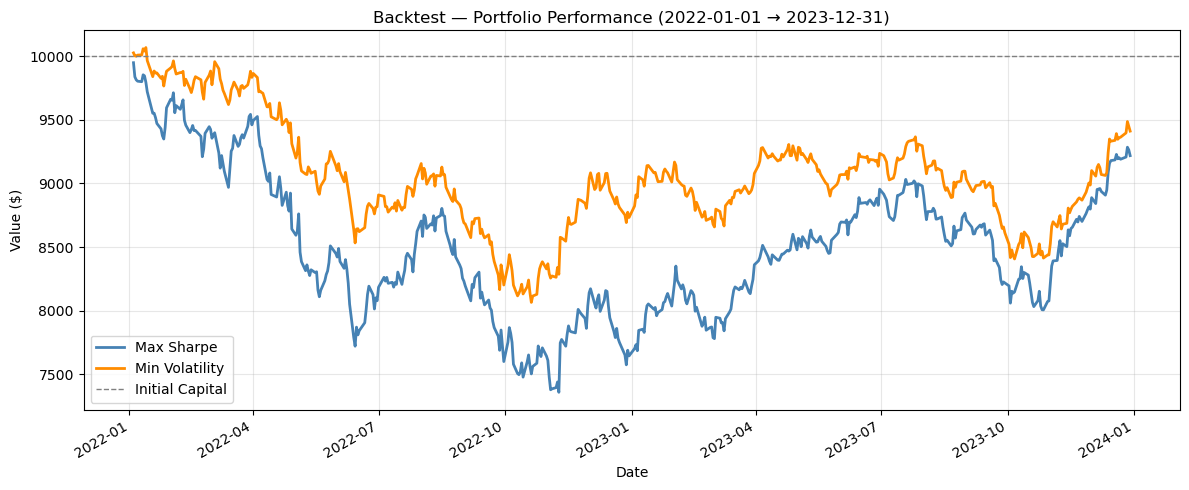

In [6]:
# ── Assets ───────────────────────────────────────────────────
assets = ["AAPL", "MSFT", "GOOGL", "AMZN", "JPM", "JNJ", "PG", "KO", "WMT", "XOM", "BRK-B", "VOO", "GLD", "TLT", "VNQ"]

# ── Download or load data ────────────────────────────────────
price_data_frame_full = get_or_create_dataset(assets)  # ← All the data

# ── Dates ────────────────────────────────────────────────────
train_start = "2010-09-09"
train_end   = "2021-12-31"
test_start  = "2022-01-01"
test_end    = "2023-12-31"

# ── Run ──────────────────────────────────────────────────────
run_all(price_data_frame_full, assets, train_start, train_end, test_start, test_end)

## Results

As expected, `TLT` dominates both portfolios at ~43%, confirming that the optimizer
trusted 11 years of bond-equity correlation. `XOM` was assigned 0% weight despite
gaining ~87% in 2022 — the model had no way to anticipate the energy shock.
`VNQ`, `GOOGL` and `AMZN` were correctly excluded.

Both portfolios lost money in the test period, with Max Sharpe at **-7.81%** and
Min Volatility at **-5.88%**. However, the S&P 500 fell ~18% that same year —
meaning the model still protected capital significantly better than the general market,
even while failing to adapt to the new regime.

# COVID-19 Crash & Recovery 2020

During 2019, markets were performing well with no major signs of trouble. In late 2019,
a new virus was detected in Wuhan, China. By March 2020 the World Health Organization
declared COVID-19 a global pandemic, triggering the fastest market crash in history —
the S&P 500 fell ~34% in just 33 days as economies worldwide shut down overnight.

The Federal Reserve and the U.S. government responded immediately with massive stimulus —
interest rates were cut back to zero and trillions of dollars were injected into the
economy. This fueled one of the fastest recoveries in market history, with most assets
fully recovering by the end of 2020.

---

## Assets

| Ticker | Description |
|--------|-------------|
| `AAPL` `MSFT` `AMZN` | Big tech, direct beneficiaries of the remote work shift |
| `NFLX` | Streaming exploded as people stayed home |
| `ZM` | Zoom became the symbol of the year, up ~400% |
| `PFE` `JNJ` | Pharma companies racing to develop a vaccine |
| `GLD` | The gold ETF, classic safe haven during uncertainty |
| `TLT` | Long-term treasury bonds, the primary flight-to-safety asset during the crash |
| `XLP` | Consumer staples, people kept buying essentials |
| `VOO` | S&P 500 ETF, general market benchmark |
| `VNQ` | REITs suffered with offices and retail spaces closed |
| `XLE` | Energy collapsed — oil prices briefly went negative in April 2020 |
| `BRK-B` | Berkshire Hathaway, broad market exposure |
| `WMT` | Walmart, essential retail that stayed open throughout |

---

## Model Limitation

This model was trained on 2015–2019 data, a period of steady growth with no major
crashes. It had never seen a pandemic-driven overnight economic shutdown. The optimizer
learned correlations from a relatively calm bull market, so its ability to anticipate
the speed and nature of the COVID crash — and more importantly the V-shape recovery
driven by unprecedented government stimulus — was limited by definition.

File not found. Downloading data for: ['AAPL', 'MSFT', 'AMZN', 'NFLX', 'ZM', 'PFE', 'JNJ', 'GLD', 'TLT', 'XLP', 'VOO', 'VNQ', 'XLE', 'BRK-B', 'WMT']
File saved at: C:\Users\carle\Documents\Portafolio Optimization\Tiingo-data\data-sets\AAPL_AMZN_BRK-B_GLD_JNJ_MSFT_NFLX_PFE_TLT_VNQ_VOO_WMT_XLE_XLP_ZM.csv
                 AAPL        MSFT     AMZN    NFLX    ZM        PFE  \
date                                                                  
2019-04-18  48.622872  115.644478  93.0845  36.035  62.0  26.865858   
2019-04-22  48.782674  116.010056  94.3655  37.734  65.7  26.592969   
2019-04-23  49.486282  117.584853  96.1885  38.189  69.0  26.893147   
2019-04-24  49.409959  117.181780  95.0875  37.423  63.2  26.859036   
2019-04-25  48.961558  121.062530  95.1125  36.833  65.0  27.022769   

                   JNJ     GLD         TLT        XLP         VOO        VNQ  \
date                                                                           
2019-04-18  113.126264  120.37  100.74

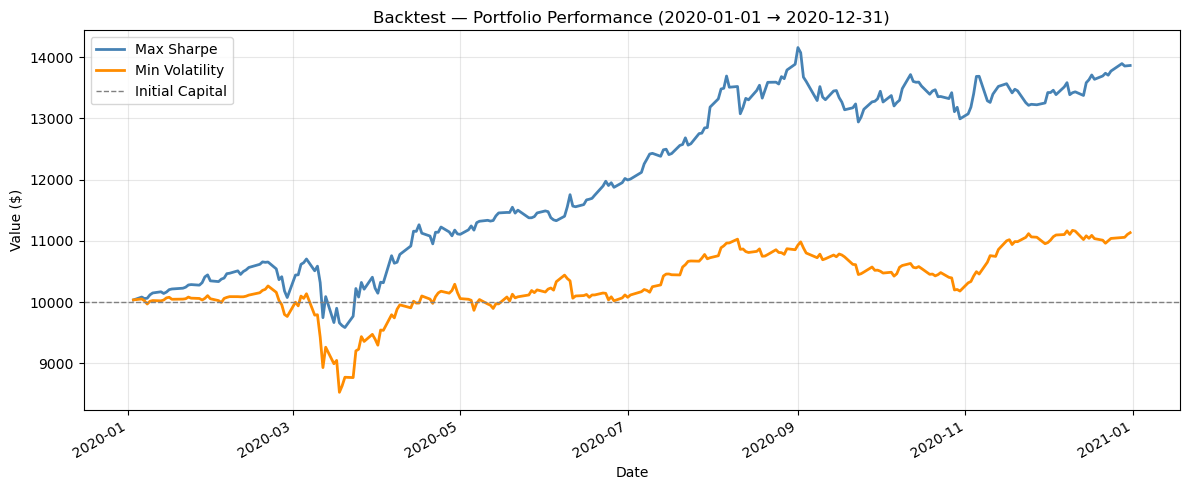

In [7]:
# ── Assets ───────────────────────────────────────────────────
assets = ["AAPL", "MSFT", "AMZN", "NFLX", "ZM", "PFE", "JNJ", "GLD", "TLT", "XLP", "VOO", "VNQ", "XLE", "BRK-B", "WMT"]

# ── Download or load data ────────────────────────────────────
price_data_frame_full = get_or_create_dataset(assets)  # ← All the data

# ── Dates ────────────────────────────────────────────────────
train_start = "2015-01-01"
train_end   = "2019-12-31"
test_start  = "2020-01-01"
test_end    = "2020-12-31"

# ── Run ──────────────────────────────────────────────────────
run_all(price_data_frame_full, assets, train_start, train_end, test_start, test_end)

## Results

Max Sharpe concentrated heavily in `GLD` at 38% and `AAPL` at 22%, which turned out
to be two of the strongest performers of 2020. `TLT` at 18% provided the cushion
during the March crash. `ZM`, `XLE`, `VNQ` and `VNQ` were all correctly excluded or
near zero.

The backtest shows **+38.63%** total return with a Max Drawdown of only **-10.45%**,
meaning the portfolio absorbed the March crash well and captured the V-shape recovery
strongly. A Sharpe of **2.09** out-of-sample is an exceptional result.

Min Volatility was more conservative, ending at **+11.34%** with a higher drawdown
of **-16.91%** — surprising given its objective. This is explained by `XLE` at 13%
and `BRK-B` at 19%, both of which suffered during the crash and recovered slower
than tech.

Overall the model behaved well in this scenario — it naturally gravitated toward
the assets that defined 2020 without ever having seen a pandemic before.